### **Android vs IOS**

In [ ]:
import pandas as pd
import re

ANDROID_FILE = "/content/MobSF_Final_Dataset_Android.xlsx"
IOS_FILE = "/content/MobSF_iOS_Final_Dataset.xlsx"

android = pd.read_excel(ANDROID_FILE)
ios = pd.read_excel(IOS_FILE)

print(set(android['App Name']))
print(set(ios['App Name']))


common_apps = set(android["App Name"]).intersection(set(ios["App Name"]))

android = android[android["App Name"].isin(common_apps)].reset_index(drop=True)
ios = ios[ios["App Name"].isin(common_apps)].reset_index(drop=True)

print(f"Common apps compared: {len(common_apps)}")

# NORMALIZE BOOLEAN COLUMNS
bool_cols_android = [
    "Uses Camera", "Uses Mic", "Uses Contacts",
    "WebView JavaScript Enabled", "Uses Location",
    "Cleartext Traffic", "Network Security Config Present"
]

bool_cols_ios = [
    "Uses Camera", "Uses Mic", "Uses Contacts",
    "WebView JavaScript Enabled",
    "Uses Location (When In Use)", "Uses Location (Always)",
    "Uses IDFA", "ATS Exception Present"
]

for col in bool_cols_android:
    android[col] = android[col].astype(str).str.upper() == "TRUE"

for col in bool_cols_ios:
    ios[col] = ios[col].astype(str).str.upper() == "TRUE"

print(common_apps)

{'Firefox', 'Maps', 'eBay', 'Adobe Scan', 'Chrome', 'Brevistay', 'NotebookLM', 'Prime Video', 'Slack', 'Aptoide', 'JioMart', 'Instagram', 'IRCTC Rail Connect', 'Tata 1mg', 'AliExpress', 'Namo Bharat', 'Calendar', 'Clock', 'Gboard', 'Kite', 'X', 'PUMA', 'Google Play Store', 'Google Play services', 'Telegram', 'Nothing Gallery', 'AJIO', 'WhatsApp', 'Spotify', 'NordVPN', 'Brave', 'Perplexity', 'Digilocker', 'Notes', 'Threads', 'MyFitnessPal', 'Bewakoof', 'BookMyShow', 'Documents', 'inshorts', 'Reddit', 'Adobe Acrobat', 'Facebook', 'My Files', 'Shazam', 'Camera', 'bigbasket', 'redBus', 'Tor Browser', 'Swiggy', 'Udemy', 'District', 'Fitbit', 'Phone', 'Calculator', 'realme Store', 'iManager', 'ixigo', 'Apple Music', 'Authenticator', 'Trello', 'Bitwarden', 'SuperVPN', 'Rapido', 'Netflix', 'Zepto', 'MakeMyTrip', 'Aarogya Setu', 'Pinterest', 'Zomato', 'Proton VPN', 'Opera Mini', 'Splitwise', 'Amazon Shopping', 'EatClub', 'Burger King', 'JioHotstar', 'CRED', 'Ola', 'H&M', 'Turbo VPN', 'Bumble', 

In [ ]:

def pii_count(series):
    return series.fillna("").apply(
        lambda x: len([i for i in x.split(",") if i.strip()])
    )

android["PII_Count_TMP"] = pii_count(android["PII Collected Types"])
ios["PII_Count_TMP"] = pii_count(ios["PII Collected Types"])


def extract_ios_version(val):
    if pd.isna(val):
        return None
    match = re.search(r'(\d+(\.\d+)?)', str(val))
    return float(match.group(1)) if match else None

android["Target_SDK_TMP"] = pd.to_numeric(
    android["Target SDK Version"], errors="coerce"
)
ios["Target_SDK_TMP"] = ios["Target SDK Version"].apply(extract_ios_version)



# Uses Location (Any)
android["Uses_Location_Any_TMP"] = android["Uses Location"]
ios["Uses_Location_Any_TMP"] = (
    ios["Uses Location (When In Use)"] | ios["Uses Location (Always)"]
)

# Uses Advertising Identifier
android["Uses_Ad_ID_TMP"] = android["Ad SDK Count"] > 0
ios["Uses_Ad_ID_TMP"] = ios["Uses IDFA"]

# Insecure Network Configuration
android["Insecure_Network_TMP"] = (
    android["Cleartext Traffic"] |
    (~android["Network Security Config Present"])
)
ios["Insecure_Network_TMP"] = ios["ATS Exception Present"]

numeric_metrics = [
    "Tracker Count",
    "Ad SDK Count",
    "Analytics SDK Count",
    "PII_Count_TMP"
]

numeric_df = pd.DataFrame({
    "Metric": numeric_metrics,
    "Android (Mean)": [round(android[m].mean(), 2) for m in numeric_metrics],
    "iOS (Mean)": [round(ios[m].mean(), 2) for m in numeric_metrics]
})

print("\n=== NUMERIC PRIVACY METRICS (COMMON APPS) ===\n")
print(numeric_df)


=== NUMERIC PRIVACY METRICS (COMMON APPS) ===

                Metric  Android (Mean)  iOS (Mean)
0        Tracker Count            4.64        0.14
1         Ad SDK Count            0.64        0.07
2  Analytics SDK Count            1.74        0.00
3        PII_Count_TMP            3.00        2.12


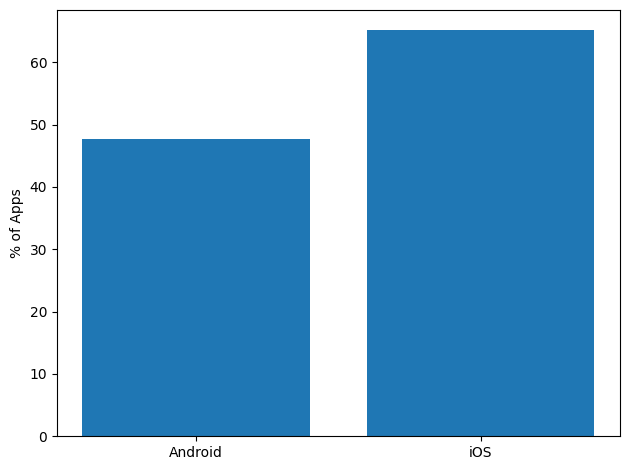

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
vals = [
    android["Insecure_Network_TMP"].mean() * 100,
    ios["Insecure_Network_TMP"].mean() * 100
]

plt.figure()
plt.bar(["Android", "iOS"], vals)
plt.ylabel("% of Apps")
# plt.title("Insecure Network Configuration Presence")
plt.tight_layout()
plt.show()


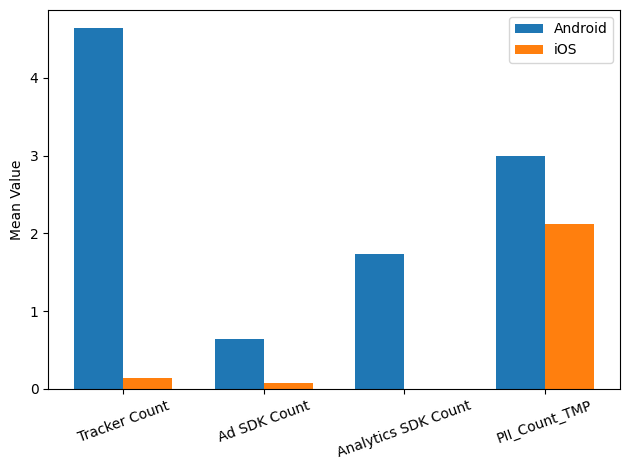

In [ ]:


metrics = [
    "Tracker Count",
    "Ad SDK Count",
    "Analytics SDK Count",
    "PII_Count_TMP"
]

android_vals = [android[m].mean() for m in metrics]
ios_vals = [ios[m].mean() for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure()
plt.bar(x - width/2, android_vals, width, label="Android")
plt.bar(x + width/2, ios_vals, width, label="iOS")

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Mean Value")
# plt.title("Mean Privacy-Relevant Metrics (Common Apps)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

boolean_metrics = [
    "Uses Camera",
    "Uses Mic",
    "Uses Contacts",
    "WebView JavaScript Enabled"
]

boolean_df = pd.DataFrame({
    "Metric": boolean_metrics,
    "Android (% Apps)": [round(android[m].mean() * 100, 2) for m in boolean_metrics],
    "iOS (% Apps)": [round(ios[m].mean() * 100, 2) for m in boolean_metrics]
})

print("\n=== PERMISSION / BEHAVIOR METRICS (COMMON APPS) ===\n")
print(boolean_df)


=== PERMISSION / BEHAVIOR METRICS (COMMON APPS) ===

                       Metric  Android (% Apps)  iOS (% Apps)
0                 Uses Camera             78.57         88.37
1                    Uses Mic             21.43         79.07
2               Uses Contacts             19.05         58.14
3  WebView JavaScript Enabled             80.95        100.00


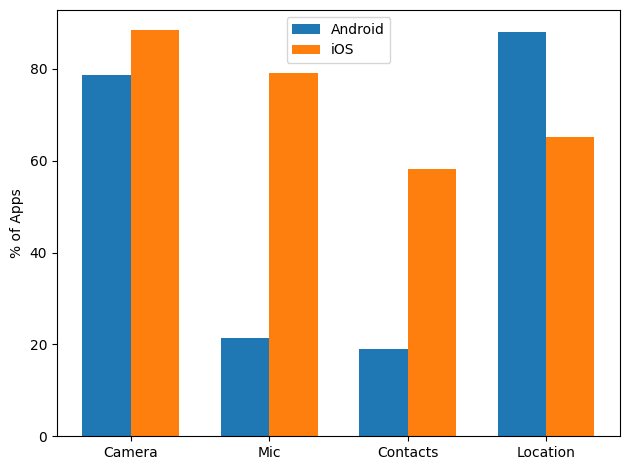

In [ ]:
perm_metrics = [
    "Uses Camera",
    "Uses Mic",
    "Uses Contacts",
    "Uses_Location_Any_TMP"
]

android_pct = [android[m].mean() * 100 for m in perm_metrics]
ios_pct = [ios[m].mean() * 100 for m in perm_metrics]

x = np.arange(len(perm_metrics))

plt.figure()
plt.bar(x - 0.35/2, android_pct, 0.35, label="Android")
plt.bar(x + 0.35/2, ios_pct, 0.35, label="iOS")

plt.xticks(x, ["Camera", "Mic", "Contacts", "Location"])
plt.ylabel("% of Apps")
# plt.title("Permission Usage Comparison (Common Apps)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

derived_df = pd.DataFrame({
    "Metric": [
        "Uses Location (Any)",
        "Uses Advertising Identifier",
        "Insecure Network Configuration"
    ],
    "Android (% Apps)": [
        round(android["Uses_Location_Any_TMP"].mean() * 100, 2),
        round(android["Uses_Ad_ID_TMP"].mean() * 100, 2),
        round(android["Insecure_Network_TMP"].mean() * 100, 2)
    ],
    "iOS (% Apps)": [
        round(ios["Uses_Location_Any_TMP"].mean() * 100, 2),
        round(ios["Uses_Ad_ID_TMP"].mean() * 100, 2),
        round(ios["Insecure_Network_TMP"].mean() * 100, 2)
    ]
})

print("\n=== DERIVED CROSS-PLATFORM PRIVACY / SECURITY METRICS ===\n")
print(derived_df)



=== DERIVED CROSS-PLATFORM PRIVACY / SECURITY METRICS ===

                           Metric  Android (% Apps)  iOS (% Apps)
0             Uses Location (Any)             88.10         65.12
1     Uses Advertising Identifier             42.86         62.79
2  Insecure Network Configuration             47.62         65.12


In [ ]:

os_df = pd.DataFrame([{
    "Metric": "Target OS Version",
    "Android (Mean API Level)": round(android["Target_SDK_TMP"].mean(), 2),
    "iOS (Mean OS Version)": round(ios["Target_SDK_TMP"].mean(), 2)
}])

print("\n=== TARGET OS / SDK ADOPTION (COMMON APPS) ===\n")
print(os_df)


=== TARGET OS / SDK ADOPTION (COMMON APPS) ===

              Metric  Android (Mean API Level)  iOS (Mean OS Version)
0  Target OS Version                     35.14                  23.29


In [ ]:

android["Sensitive_Perm_Count_TMP"] = (
    android["Uses Camera"].astype(int) +
    android["Uses Mic"].astype(int) +
    android["Uses Location"].astype(int) +
    android["Uses Contacts"].astype(int) +
    android["Uses SMS"].astype(int)
)

ios["Sensitive_Perm_Count_TMP"] = (
    ios["Uses Camera"].astype(int) +
    ios["Uses Mic"].astype(int) +
    ios["Uses_Location_Any_TMP"].astype(int) +
    ios["Uses Contacts"].astype(int)
)

sensitive_perm_df = pd.DataFrame({
    "Metric": ["Sensitive Permission Count"],
    "Android (Mean)": [round(android["Sensitive_Perm_Count_TMP"].mean(), 2)],
    "iOS (Mean)": [round(ios["Sensitive_Perm_Count_TMP"].mean(), 2)]
})

print("\n=== SENSITIVE PERMISSION COUNT ===\n")
print(sensitive_perm_df)




=== SENSITIVE PERMISSION COUNT ===

                       Metric  Android (Mean)  iOS (Mean)
0  Sensitive Permission Count            2.26        2.91


In [ ]:

def tracking_intensity(count):
    if pd.isna(count) or count == 0:
        return "None"
    elif count <= 2:
        return "Low"
    elif count <= 5:
        return "Medium"
    else:
        return "High"

android["Tracking_Intensity_TMP"] = android["Tracker Count"].apply(tracking_intensity)
ios["Tracking_Intensity_TMP"] = ios["Tracker Count"].apply(tracking_intensity)

tracking_intensity_df = pd.DataFrame({
    "Intensity Level": ["None", "Low", "Medium", "High"],
    "Android (%)": [
        round((android["Tracking_Intensity_TMP"] == lvl).mean() * 100, 2)
        for lvl in ["None", "Low", "Medium", "High"]
    ],
    "iOS (%)": [
        round((ios["Tracking_Intensity_TMP"] == lvl).mean() * 100, 2)
        for lvl in ["None", "Low", "Medium", "High"]
    ]
})

print("\n=== TRACKING INTENSITY DISTRIBUTION ===\n")
print(tracking_intensity_df)



=== TRACKING INTENSITY DISTRIBUTION ===

  Intensity Level  Android (%)  iOS (%)
0            None         9.52     90.7
1             Low        21.43      9.3
2          Medium        26.19      0.0
3            High        42.86      0.0


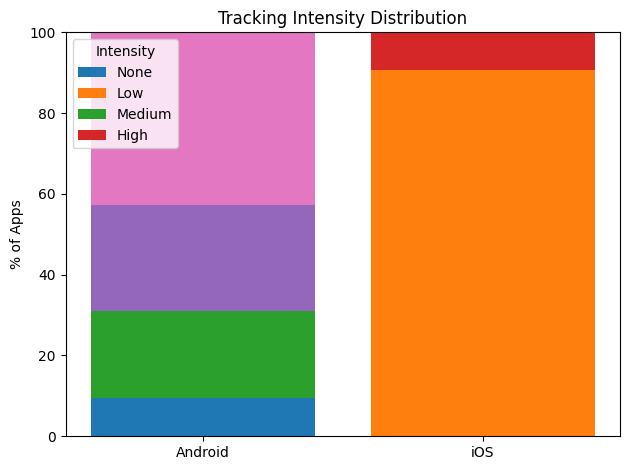

In [ ]:
levels = ["None", "Low", "Medium", "High"]

android_dist = [
    (android["Tracking_Intensity_TMP"] == lvl).mean() * 100
    for lvl in levels
]

ios_dist = [
    (ios["Tracking_Intensity_TMP"] == lvl).mean() * 100
    for lvl in levels
]

x = np.arange(2)

plt.figure()
bottom_android = 0
bottom_ios = 0

for i, lvl in enumerate(levels):
    plt.bar(0, android_dist[i], bottom=bottom_android, label=lvl if i == 0 else "")
    plt.bar(1, ios_dist[i], bottom=bottom_ios)
    bottom_android += android_dist[i]
    bottom_ios += ios_dist[i]

plt.xticks(x, ["Android", "iOS"])
plt.ylabel("% of Apps")
plt.title("Tracking Intensity Distribution")
plt.legend(levels, title="Intensity")
plt.tight_layout()
plt.show()


In [ ]:

android["Web_Attack_Surface_TMP"] = (
    android["WebView JavaScript Enabled"] |
    android["Browsable Activities Present"]
)

ios["Web_Attack_Surface_TMP"] = (
    ios["WebView JavaScript Enabled"] |
    ios["Uses Custom URL Schemes"]
)

web_attack_df = pd.DataFrame({
    "Metric": ["Web Attack Surface Present"],
    "Android (% Apps)": [round(android["Web_Attack_Surface_TMP"].mean() * 100, 2)],
    "iOS (% Apps)": [round(ios["Web_Attack_Surface_TMP"].mean() * 100, 2)]
})

print("\n=== WEB ATTACK SURFACE COMPARISON ===\n")
print(web_attack_df)


=== WEB ATTACK SURFACE COMPARISON ===

                       Metric  Android (% Apps)  iOS (% Apps)
0  Web Attack Surface Present             97.62         100.0


### **PRI**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:


pri_features = [
    "Tracker Count",
    "Ad SDK Count",
    "Analytics SDK Count",
    "PII_Count_TMP",
    "Sensitive_Perm_Count_TMP",
    "Uses_Ad_ID_TMP",
    "Insecure_Network_TMP",
    "Web_Attack_Surface_TMP"
]


In [ ]:
android_pri_data = android[pri_features].copy()
ios_pri_data = ios[pri_features].copy()

# booleans → int
android_pri_data = android_pri_data.astype(int, errors="ignore")
ios_pri_data = ios_pri_data.astype(int, errors="ignore")


In [ ]:
scaler = StandardScaler()

android_scaled = scaler.fit_transform(android_pri_data)
ios_scaled = scaler.fit_transform(ios_pri_data)


In [ ]:
pca = PCA(n_components=1)

android["PRI_TMP"] = pca.fit_transform(android_scaled).flatten()
android_pca_variance = pca.explained_variance_ratio_[0]

ios["PRI_TMP"] = pca.fit_transform(ios_scaled).flatten()
ios_pca_variance = pca.explained_variance_ratio_[0]


In [ ]:
def normalize(series):
    return 100 * (series - series.min()) / (series.max() - series.min())

android["PRI_Score"] = normalize(android["PRI_TMP"])
ios["PRI_Score"] = normalize(ios["PRI_TMP"])


In [ ]:
pri_df = pd.DataFrame({
    "Platform": ["Android", "iOS"],
    "Mean PRI Score": [
        round(android["PRI_Score"].mean(), 2),
        round(ios["PRI_Score"].mean(), 2)
    ],
    "Median PRI Score": [
        round(android["PRI_Score"].median(), 2),
        round(ios["PRI_Score"].median(), 2)
    ],
    "Max PRI Score": [
        round(android["PRI_Score"].max(), 2),
        round(ios["PRI_Score"].max(), 2)
    ],
    "Variance Explained by PCA (%)": [
        round(android_pca_variance * 100, 2),
        round(ios_pca_variance * 100, 2)
    ]
})

print("\n=== PRIVACY RISK INDEX (PCA-BASED) ===\n")
print(pri_df)



=== PRIVACY RISK INDEX (PCA-BASED) ===

  Platform  Mean PRI Score  Median PRI Score  Max PRI Score  \
0  Android           56.15             49.42          100.0   
1      iOS           63.31             71.38          100.0   

   Variance Explained by PCA (%)  
0                          37.22  
1                          36.48  


In [ ]:
loadings = pd.DataFrame(
    pca.components_[0],
    index=pri_features,
    columns=["PCA_Weight"]
).sort_values(by="PCA_Weight", ascending=False)

print(loadings)


                          PCA_Weight
Sensitive_Perm_Count_TMP    0.597524
PII_Count_TMP               0.577596
Uses_Ad_ID_TMP              0.402484
Insecure_Network_TMP        0.313448
Tracker Count               0.173417
Ad SDK Count                0.137957
Analytics SDK Count        -0.000000
Web_Attack_Surface_TMP      0.000000


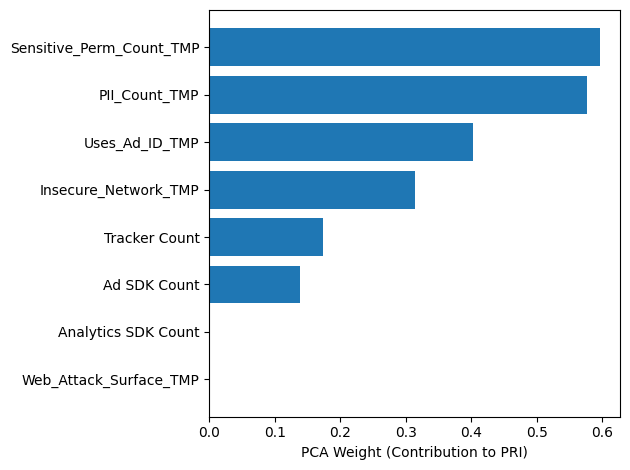

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(loadings.index, loadings["PCA_Weight"])
plt.xlabel("PCA Weight (Contribution to PRI)")
# plt.title("Feature Contribution to Privacy Risk Index (PC1)")
plt.gca().invert_yaxis()  # Highest weight on top
plt.tight_layout()
plt.show()


/tmp/ipykernel_17393/2066945577.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


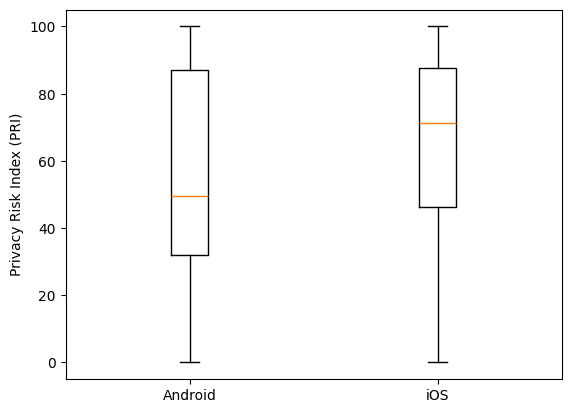

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(
    [android["PRI_Score"], ios["PRI_Score"]],
    labels=["Android", "iOS"]
)
plt.ylabel("Privacy Risk Index (PRI)")
# plt.title("PRI Distribution for Common Apps")
plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    android["PRI_Score"],
    ios["PRI_Score"],
    alternative="two-sided"
)

print("Mann–Whitney U p-value:", p)


Mann–Whitney U p-value: 0.27733084422135634


In [ ]:
app_name = "WhatsApp"

# -------- FILTER APP --------
android_row = android[android["App Name"].str.contains(app_name, case=False, na=False)].iloc[0]
ios_row = ios[ios["App Name"].str.contains(app_name, case=False, na=False)].iloc[0]


# -------- ANDROID FEATURES --------
print("\n📱 ANDROID (WhatsApp)")

print("Trackers:", android_row.get("Tracker Count"))
print("Dangerous Permissions:", android_row.get("Dangerous Permissions"))
print("PII Collected:", android_row.get("PII Collected Types"))
print("Ad SDKs:", android_row.get("Ad SDK Count"))

# Network
print("Network:", "Cleartext Allowed" if android_row.get("Cleartext Traffic") else "Secure")

# Access
print("Location:", "Yes" if android_row.get("Uses Location") else "No")
print("Camera:", "Yes" if android_row.get("Uses Camera") else "No")
print("Mic:", "Yes" if android_row.get("Uses Mic") else "No")


# -------- ANDROID PRI --------
print("PRI:", android_row.get("PRI_Score"))


# -------- iOS FEATURES --------
print("\n🍎 iOS (WhatsApp)")

print("Trackers:", ios_row.get("Tracker Count"))
print("Dangerous Permissions:", ios_row.get("Dangerous Permissions"))
print("PII Collected:", ios_row.get("PII Collected Types"))
print("Ad SDKs:", ios_row.get("Ad SDK Count"))

# Network (ATS mapping)
print("Network:", "Less Secure" if ios_row.get("ATS Exception Present") else "Secure")

# Access
location_ios = (
    ios_row.get("Uses Location (When In Use)") or
    ios_row.get("Uses Location (Always)")
)
print("Location:", "Yes" if location_ios else "No")

print("Camera:", "Yes" if ios_row.get("Uses Camera") else "No")
print("Mic:", "Yes" if ios_row.get("Uses Mic") else "No")


# -------- iOS PRI --------
print("PRI:", ios_row.get("PRI_Score"))


📱 ANDROID (WhatsApp)
Trackers: 1
Dangerous Permissions: 32
PII Collected: Contacts, Credentials, DeviceID, Email, Image/Video, Location
Ad SDKs: 0
Network: Secure
Location: Yes
Camera: Yes
Mic: Yes
PRI: 27.81027993567547

🍎 iOS (WhatsApp)
Trackers: 0
Dangerous Permissions: 11
PII Collected: Location, Contacts, Photos
Ad SDKs: 0
Network: Less Secure
Location: Yes
Camera: Yes
Mic: Yes
PRI: 76.8626435019026


Category Wise

In [ ]:
android_cat = android.copy()
ios_cat = ios.copy()

In [ ]:
CATEGORY_MAP = {

    "WhatsApp": "Social & Communication",
    "Instagram": "Social & Communication",
    "Facebook": "Social & Communication",
    "Telegram": "Social & Communication",
    "Threads": "Social & Communication",
    "Reddit": "Social & Communication",
    "Bumble": "Social & Communication",
    "Slack": "Social & Communication",

    "Netflix": "Entertainment & Streaming",
    "Spotify": "Entertainment & Streaming",
    "Sony LIV": "Entertainment & Streaming",
    "JioHotstar": "Entertainment & Streaming",
    "BookMyShow": "Entertainment & Streaming",
    "District": "Entertainment & Streaming",
    "Shazam": "Entertainment & Streaming",

    "H&M": "Shopping & E-commerce",
    "Zepto": "Shopping & E-commerce",
    "Blinkit": "Shopping & E-commerce",
    "JioMart": "Shopping & E-commerce",
    "CRED": "Shopping & E-commerce",
    "EatClub": "Shopping & E-commerce",

    "Zomato": "Travel & Food",
    "Swiggy": "Travel & Food",
    "MakeMyTrip": "Travel & Food",
    "redBus": "Travel & Food",
    "Brevistay": "Travel & Food",
    "Burger King": "Travel & Food",

    "Namo Bharat": "Health",
    "IRCTC Rail Connect": "Health",
    "Digilocker": "Health",
    "Authenticator": "Health",

    "Udemy": "Education & Productivity",
    "NotebookLM": "Education & Productivity",
    "Perplexity": "Education & Productivity",
    "GitHub": "Education & Productivity",
    "Trello": "Education & Productivity",
    "Simplenote": "Education & Productivity",

    "Kite": "Finance & Utilities",
    "Splitwise": "Finance & Utilities",
    "Bitwarden": "Finance & Utilities",
}


In [ ]:
android["Category"] = android["App Name"].map(CATEGORY_MAP)
ios["Category"] = ios["App Name"].map(CATEGORY_MAP)

# Drop apps without a category (very important)
android_cat = android.dropna(subset=["Category"]).copy()
ios_cat = ios.dropna(subset=["Category"]).copy()

print("Android apps with category:", len(android_cat))
print("iOS apps with category:", len(ios_cat))

Android apps with category: 40
iOS apps with category: 41


In [ ]:
common_cat_apps = set(android_cat["App Name"]).intersection(
    set(ios_cat["App Name"])
)

print("Common categorized apps:", len(common_cat_apps))
print(common_cat_apps)

Common categorized apps: 40
{'Telegram', 'WhatsApp', 'Swiggy', 'Udemy', 'Spotify', 'EatClub', 'Perplexity', 'Burger King', 'Brevistay', 'Digilocker', 'District', 'NotebookLM', 'Threads', 'JioHotstar', 'CRED', 'H&M', 'Slack', 'Bumble', 'Authenticator', 'BookMyShow', 'Reddit', 'Trello', 'Bitwarden', 'Simplenote', 'JioMart', 'Instagram', 'IRCTC Rail Connect', 'Netflix', 'Zepto', 'MakeMyTrip', 'Facebook', 'GitHub', 'Namo Bharat', 'Zomato', 'Blinkit', 'Kite', 'Shazam', 'Splitwise', 'Sony LIV', 'redBus'}


In [ ]:
android_cat_common = android_cat[
    android_cat["App Name"].isin(common_cat_apps)
].copy()

ios_cat_common = ios_cat[
    ios_cat["App Name"].isin(common_cat_apps)
].copy()


android_cat_count = (
    android_cat_common
    .groupby("Category")["App Name"]
    .nunique()
    .reset_index()
    .rename(columns={"App Name": "Android App Count"})
)

print("Android (common + categorized):", len(android_cat_common))
print("iOS (common + categorized):", len(ios_cat_common))
print(android_cat_count)

Android (common + categorized): 40
iOS (common + categorized): 41
                    Category  Android App Count
0   Education & Productivity                  6
1  Entertainment & Streaming                  7
2        Finance & Utilities                  3
3                     Health                  4
4      Shopping & E-commerce                  6
5     Social & Communication                  8
6              Travel & Food                  6


In [ ]:
android_cat_pri = (
    android_cat_common
    .groupby("Category")["PRI_Score"]
    .mean()
    .reset_index()
    .rename(columns={"PRI_Score": "Android Mean PRI"})
)

ios_cat_pri = (
    ios_cat_common
    .groupby("Category")["PRI_Score"]
    .mean()
    .reset_index()
    .rename(columns={"PRI_Score": "iOS Mean PRI"})
)

category_pri_df = pd.merge(
    android_cat_pri,
    ios_cat_pri,
    on="Category",
    how="inner"
).sort_values(by="Android Mean PRI", ascending=False)

print("\n=== CROSS-PLATFORM CATEGORY-WISE PRIVACY RISK ===\n")
print(category_pri_df)


=== CROSS-PLATFORM CATEGORY-WISE PRIVACY RISK ===

                    Category  Android Mean PRI  iOS Mean PRI
6              Travel & Food         85.159579     80.084350
4      Shopping & E-commerce         79.333942     87.692699
1  Entertainment & Streaming         65.504480     58.928827
3                     Health         42.324282     27.840649
0   Education & Productivity         40.827867     47.628689
5     Social & Communication         39.283340     75.645670
2        Finance & Utilities         32.315874     26.491548


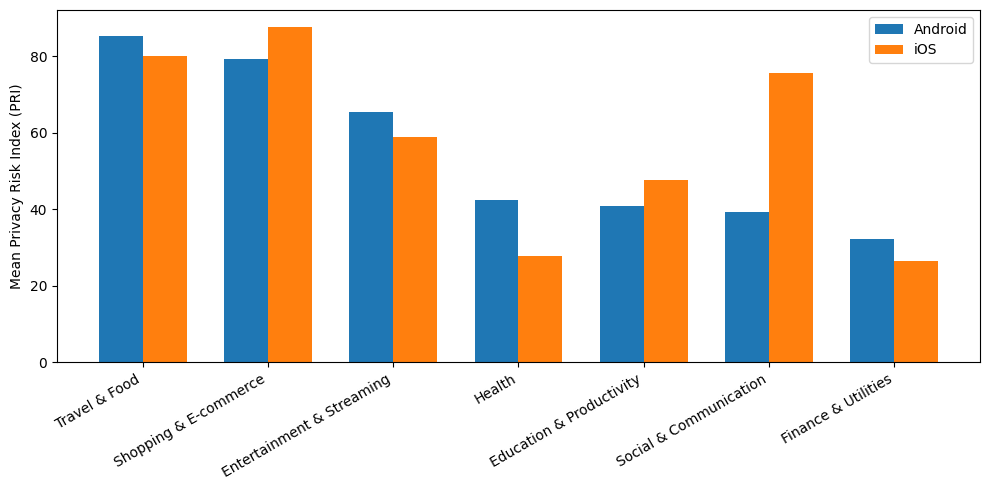

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(category_pri_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, category_pri_df["Android Mean PRI"], width, label="Android")
plt.bar(x + width/2, category_pri_df["iOS Mean PRI"], width, label="iOS")

plt.xticks(x, category_pri_df["Category"], rotation=30, ha="right")
plt.ylabel("Mean Privacy Risk Index (PRI)")
# plt.title("Category-wise Privacy Risk: Android vs iOS (Common Apps)")
plt.legend()
plt.tight_layout()
plt.show()

### **Pre-Installed vs User-Installed**

In [ ]:


android_all = pd.read_excel(ANDROID_FILE)

# Normalize Preinstalled App column
android_all["Preinstalled App"] = (
    android_all["Preinstalled App"].astype(str).str.upper() == "TRUE"
)

android_preinstalled = android_all[
    android_all["Preinstalled App"] == True
].reset_index(drop=True)

android_user = android_all[
    android_all["Preinstalled App"] == False
].reset_index(drop=True)

print(f"Total Android apps: {len(android_all)}")
print(f"Preinstalled apps: {len(android_preinstalled)}")
print(f"User-installed apps: {len(android_user)}")

print(set(android_user['App Name']))


Total Android apps: 100
Preinstalled apps: 22
User-installed apps: 78
{'Firefox', 'eBay', 'Adobe Scan', 'Chrome', 'Brevistay', 'NotebookLM', 'Prime Video', 'Slack', 'Aptoide', 'JioMart', 'Instagram', 'IRCTC Rail Connect', 'Tata 1mg', 'AliExpress', 'Namo Bharat', 'X', 'Kite', 'PUMA', 'Telegram', 'AJIO', 'WhatsApp', 'Spotify', 'NordVPN', 'Brave', 'Perplexity', 'Digilocker', 'Threads', 'MyFitnessPal', 'Bewakoof', 'BookMyShow', 'inshorts', 'Reddit', 'Adobe Acrobat', 'Facebook', 'Shazam', 'bigbasket', 'redBus', 'Tor Browser', 'Swiggy', 'Udemy', 'District', 'Fitbit', 'Calculator', 'realme Store', 'ixigo', 'Apple Music', 'Authenticator', 'Trello', 'Bitwarden', 'SuperVPN', 'Rapido', 'Netflix', 'Zepto', 'MakeMyTrip', 'Aarogya Setu', 'Pinterest', 'Zomato', 'Proton VPN', 'Opera Mini', 'Splitwise', 'Amazon Shopping', 'EatClub', 'Burger King', 'JioHotstar', 'CRED', 'Ola', 'H&M', 'Turbo VPN', 'Bumble', 'Signal', 'Where is My Train', 'Simplenote', 'Dolphin', 'GitHub', 'Blinkit', 'InShot', 'Sony LIV',

In [ ]:
bool_cols = [
    "Uses Camera", "Uses Mic", "Uses Contacts",
    "Uses Location", "Uses SMS",
    "WebView JavaScript Enabled",
    "Cleartext Traffic",
    "Network Security Config Present",
    "Browsable Activities Present"
]

for col in bool_cols:
    if col in android_preinstalled.columns:
        android_preinstalled[col] = (
            android_preinstalled[col].astype(str).str.upper() == "TRUE"
        )


In [ ]:
android_preinstalled["Uses_Location_Any_TMP"] = android_preinstalled["Uses Location"]
android_preinstalled["Uses_Ad_ID_TMP"] = android_preinstalled["Ad SDK Count"] > 0
android_preinstalled["Insecure_Network_TMP"] = (
    android_preinstalled["Cleartext Traffic"] |
    (~android_preinstalled["Network Security Config Present"])
)
android_preinstalled["Sensitive_Perm_Count_TMP"] = (
    android_preinstalled["Uses Camera"].astype(int) +
    android_preinstalled["Uses Mic"].astype(int) +
    android_preinstalled["Uses Location"].astype(int) +
    android_preinstalled["Uses Contacts"].astype(int) +
    android_preinstalled["Uses SMS"].astype(int)
)


In [ ]:
preinstalled_numeric_df = pd.DataFrame({
    "Metric": [
        "Tracker Count",
        "Ad SDK Count",
        "Analytics SDK Count",
        "Sensitive Permission Count"
    ],
    "Mean Value": [
        round(android_preinstalled["Tracker Count"].mean(), 2),
        round(android_preinstalled["Ad SDK Count"].mean(), 2),
        round(android_preinstalled["Analytics SDK Count"].mean(), 2),
        round(android_preinstalled["Sensitive_Perm_Count_TMP"].mean(), 2)
    ]
})

print("\n=== PREINSTALLED APPS: NUMERIC METRICS ===\n")
print(preinstalled_numeric_df)



=== PREINSTALLED APPS: NUMERIC METRICS ===

                       Metric  Mean Value
0               Tracker Count        0.50
1                Ad SDK Count        0.09
2         Analytics SDK Count        0.23
3  Sensitive Permission Count        1.64


In [ ]:
preinstalled_bool_df = pd.DataFrame({
    "Metric": [
        "Uses Camera",
        "Uses Mic",
        "Uses Location (Any)",
        "Uses Contacts",
        "Uses Advertising Identifier",
        "Insecure Network Configuration",
        "WebView JavaScript Enabled",
        "Browsable Activities Present"
    ],
    "% Apps": [
        round(android_preinstalled["Uses Camera"].mean() * 100, 2),
        round(android_preinstalled["Uses Mic"].mean() * 100, 2),
        round(android_preinstalled["Uses_Location_Any_TMP"].mean() * 100, 2),
        round(android_preinstalled["Uses Contacts"].mean() * 100, 2),
        round(android_preinstalled["Uses_Ad_ID_TMP"].mean() * 100, 2),
        round(android_preinstalled["Insecure_Network_TMP"].mean() * 100, 2),
        round(android_preinstalled["WebView JavaScript Enabled"].mean() * 100, 2),
        round(android_preinstalled["Browsable Activities Present"].mean() * 100, 2)
    ]
})

print("\n=== PREINSTALLED APPS: PRIVACY / SECURITY METRICS ===\n")
print(preinstalled_bool_df)



=== PREINSTALLED APPS: PRIVACY / SECURITY METRICS ===

                           Metric  % Apps
0                     Uses Camera   36.36
1                        Uses Mic   18.18
2             Uses Location (Any)   54.55
3                   Uses Contacts   31.82
4     Uses Advertising Identifier    9.09
5  Insecure Network Configuration   68.18
6      WebView JavaScript Enabled   54.55
7    Browsable Activities Present   63.64


In [ ]:

android_user["Sensitive_Perm_Count_TMP"] = (
    android_user["Uses Camera"].astype(int) +
    android_user["Uses Mic"].astype(int) +
    android_user["Uses Location"].astype(int) +
    android_user["Uses Contacts"].astype(int) +
    android_user["Uses SMS"].astype(int)
)


In [ ]:
compare_android_df = pd.DataFrame({
    "Metric": [
        "Tracker Count",
        "Sensitive Permission Count",
        "Uses Advertising Identifier (%)",
        "Insecure Network Configuration (%)"
    ],
    "User-installed Android": [
        round(android_user["Tracker Count"].mean(), 2),
        round(android_user["Sensitive_Perm_Count_TMP"].mean(), 2),
        round((android_user["Ad SDK Count"] > 0).mean() * 100, 2),
        round(
            (
                android_user["Cleartext Traffic"] |
                (~android_user["Network Security Config Present"])
            ).mean() * 100, 2
        )
    ],
    "Preinstalled Android": [
        round(android_preinstalled["Tracker Count"].mean(), 2),
        round(android_preinstalled["Sensitive_Perm_Count_TMP"].mean(), 2),
        round(android_preinstalled["Uses_Ad_ID_TMP"].mean() * 100, 2),
        round(android_preinstalled["Insecure_Network_TMP"].mean() * 100, 2)
    ]
})

print("\n=== ANDROID: USER-INSTALLED vs PREINSTALLED COMPARISON ===\n")
print(compare_android_df)



=== ANDROID: USER-INSTALLED vs PREINSTALLED COMPARISON ===

                               Metric  User-installed Android  \
0                       Tracker Count                    5.22   
1          Sensitive Permission Count                    2.18   
2     Uses Advertising Identifier (%)                   50.00   
3  Insecure Network Configuration (%)                   42.31   

   Preinstalled Android  
0                  0.50  
1                  1.64  
2                  9.09  
3                 68.18  


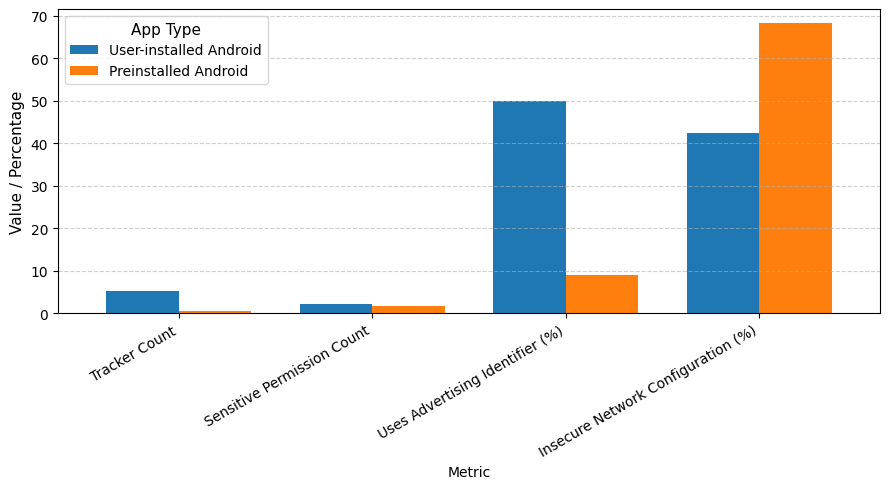

In [ ]:
df_plot = compare_android_df.set_index("Metric")

ax = df_plot.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.75
)

# Title and labels
# ax.set_title(
#     "Android Apps: User-installed vs Preinstalled Comparison",
#     fontsize=14,
#     pad=12
# )

ax.set_ylabel("Value / Percentage", fontsize=11)

plt.xticks(rotation=30, ha="right")

ax.legend(
    title="App Type",
    fontsize=10,
    title_fontsize=11
)

ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

### **Play Store Reviews vs Our Results (Android)**

In [ ]:
reviews = pd.read_csv("/content/User_Perception_Privacy_Dataset.csv")

In [ ]:
merged_android = pd.merge(
    android_user,
    reviews,
    on="Package Name",
    how="inner"
)

print("User-installed apps with reviews:", merged_android.shape[0])


User-installed apps with reviews: 75


In [ ]:
comparison_pairs = {

    "Uses Camera": "Camera_Trust_Score",
    "Uses Location": "Location_Trust_Score",
    "Uses Mic": "Microphone_Trust_Score",
    "Uses Contacts": "Contacts_Trust_Score",
    "Sensitive_Perm_Count_TMP": "Data_Privacy_Trust_Score",
    "Tracker Count": "Tracking_Ads_Trust_Score",
    "Cleartext Traffic": "Network_Security_Trust_Score",
    "Uses Weak Cryptography": "Cryptography_Trust_Score",
    "WebView JavaScript Enabled": "Security_Issues_Trust_Score"
}


In [ ]:
corr_rows = []

for static_col, sentiment_col in comparison_pairs.items():
    if static_col not in merged_android.columns:
        print(f"[SKIP] Missing static column: {static_col}")
        continue

    if sentiment_col not in merged_android.columns:
        print(f"[SKIP] Missing sentiment column: {sentiment_col}")
        continue

    corr = merged_android[static_col].corr(
        merged_android[sentiment_col]
    )

    corr_rows.append({
        "Static Metric (MobSF)": static_col,
        "User Sentiment Metric": sentiment_col,
        "Pearson Correlation": round(corr, 3)
    })

corr_df = pd.DataFrame(corr_rows)
corr_df


,Static Metric (MobSF),User Sentiment Metric,Pearson Correlation
0,Uses Camera,Camera_Trust_Score,-0.183
1,Uses Location,Location_Trust_Score,-0.360
2,Uses Mic,Microphone_Trust_Score,0.047
3,Uses Contacts,Contacts_Trust_Score,-0.016
4,Sensitive_Perm_Count_TMP,Data_Privacy_Trust_Score,-0.139
5,Tracker Count,Tracking_Ads_Trust_Score,-0.296
6,Cleartext Traffic,Network_Security_Trust_Score,0.294
7,Uses Weak Cryptography,Cryptography_Trust_Score,0.009
8,WebView JavaScript Enabled,Security_Issues_Trust_Score,-0.312


In [ ]:
from scipy.stats import spearmanr

rows = []

for static_col, sentiment_col in comparison_pairs.items():
    rho, p = spearmanr(
        merged_android[static_col],
        merged_android[sentiment_col],
        nan_policy="omit"
    )

    rows.append({
        "Static Metric": static_col,
        "Sentiment Metric": sentiment_col,
        "Spearman ρ": round(rho, 3),
        "p-value": round(p, 4)
    })

spearman_df = pd.DataFrame(rows)
spearman_df


,Static Metric,Sentiment Metric,Spearman ρ,p-value
0,Uses Camera,Camera_Trust_Score,-0.169,0.1463
1,Uses Location,Location_Trust_Score,-0.346,0.0024
2,Uses Mic,Microphone_Trust_Score,0.062,0.5962
3,Uses Contacts,Contacts_Trust_Score,0.017,0.8870
4,Sensitive_Perm_Count_TMP,Data_Privacy_Trust_Score,-0.147,0.2085
5,Tracker Count,Tracking_Ads_Trust_Score,-0.379,0.0008
6,Cleartext Traffic,Network_Security_Trust_Score,0.232,0.0450
7,Uses Weak Cryptography,Cryptography_Trust_Score,-0.011,0.9224
8,WebView JavaScript Enabled,Security_Issues_Trust_Score,-0.326,0.0044


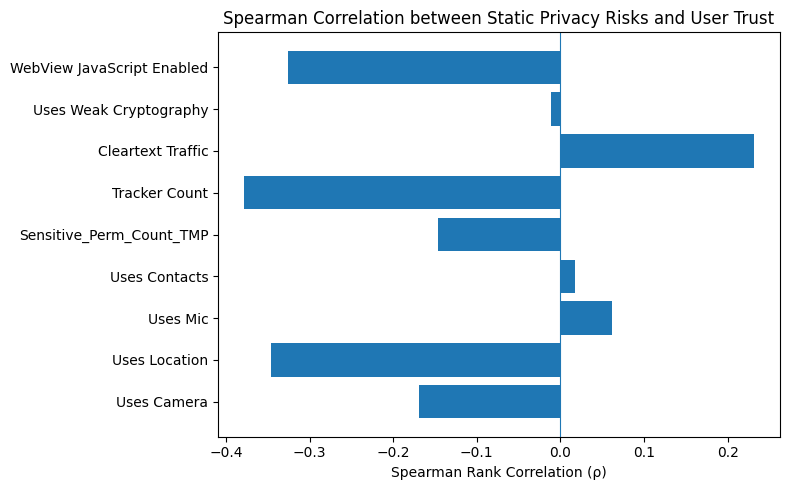

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(
    spearman_df["Static Metric"],
    spearman_df["Spearman ρ"]
)

plt.axvline(0, linewidth=0.8)  # zero reference line
plt.xlabel("Spearman Rank Correlation (ρ)")
plt.title("Spearman Correlation between Static Privacy Risks and User Trust")
plt.tight_layout()
plt.show()


### **iOS**

In [ ]:
IOS_FILE = "/content/MobSF_iOS_Final_Dataset.xlsx"
ios = pd.read_excel(IOS_FILE)
print(f"Total iOS apps analysed: {len(ios)}")

Total iOS apps analysed: 120


In [ ]:

# NORMALIZE BOOLEAN COLUMNS
bool_cols_ios = [
    "Uses Camera",
    "Uses Mic",
    "Uses Contacts",
    "Uses Location (When In Use)",
    "Uses Location (Always)",
    "Uses IDFA",
    "ATS Exception Present",
    "WebView JavaScript Enabled",
    "Uses Custom URL Schemes"
]

for col in bool_cols_ios:
    ios[col] = ios[col].astype(str).str.upper() == "TRUE"

In [ ]:

ios["Uses_Location_Any_TMP"] = (
    ios["Uses Location (When In Use)"] |
    ios["Uses Location (Always)"]
)

ios["Sensitive_Perm_Count_TMP"] = (
    ios["Uses Camera"].astype(int) +
    ios["Uses Mic"].astype(int) +
    ios["Uses_Location_Any_TMP"].astype(int) +
    ios["Uses Contacts"].astype(int)
)

ios["Web_Attack_Surface_TMP"] = (
    ios["WebView JavaScript Enabled"] |
    ios["Uses Custom URL Schemes"]
)

def tracking_intensity(count):
    if pd.isna(count) or count == 0:
        return "None"
    elif count <= 2:
        return "Low"
    elif count <= 5:
        return "Medium"
    else:
        return "High"

ios["Tracking_Intensity_TMP"] = ios["Tracker Count"].apply(tracking_intensity)

def pii_count(series):
    return series.fillna("").apply(
        lambda x: len([i for i in x.split(",") if i.strip()])
    )

ios["PII_Count_TMP"] = pii_count(ios["PII Collected Types"])

In [ ]:

numeric_ios_df = pd.DataFrame({
    "Metric": [
        "Tracker Count",
        "Ad SDK Count",
        "Analytics SDK Count",
        "PII Count",
        "Sensitive Permission Count"
    ],
    "Mean Value": [
        round(ios["Tracker Count"].mean(), 2),
        round(ios["Ad SDK Count"].mean(), 2),
        round(ios["Analytics SDK Count"].mean(), 2),
        round(ios["PII_Count_TMP"].mean(), 2),
        round(ios["Sensitive_Perm_Count_TMP"].mean(), 2)
    ]
})

print("\n=== iOS NUMERIC PRIVACY METRICS (ALL APPS) ===\n")
print(numeric_ios_df)


=== iOS NUMERIC PRIVACY METRICS (ALL APPS) ===

                       Metric  Mean Value
0               Tracker Count        0.55
1                Ad SDK Count        0.10
2         Analytics SDK Count        0.07
3                   PII Count        1.79
4  Sensitive Permission Count        2.44


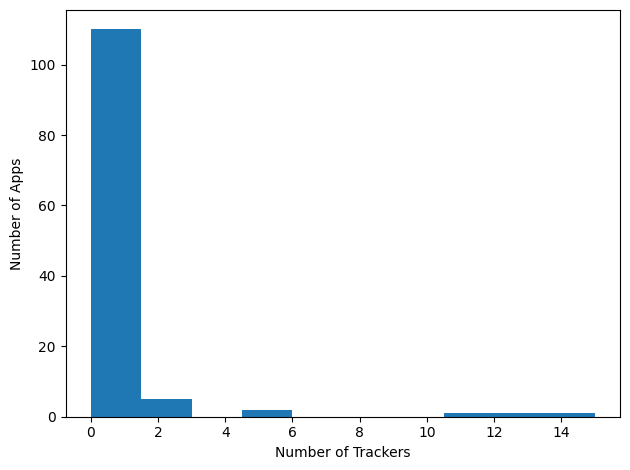

In [ ]:
plt.figure()
plt.hist(ios["Tracker Count"], bins=10)
plt.xlabel("Number of Trackers")
plt.ylabel("Number of Apps")
# plt.title("Tracker Count Distribution in iOS Apps")
plt.tight_layout()
plt.show()


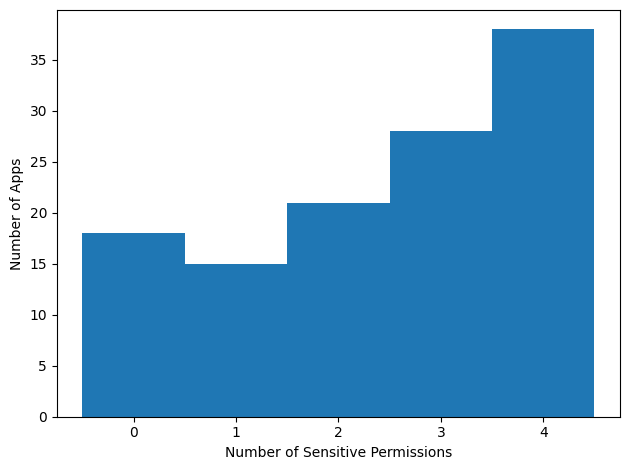

In [ ]:
plt.figure()
plt.hist(ios["Sensitive_Perm_Count_TMP"], bins=range(0, 6), align="left")
plt.xlabel("Number of Sensitive Permissions")
plt.ylabel("Number of Apps")
# plt.title("Distribution of Sensitive Permission Usage in iOS Apps")
plt.xticks(range(0, 5))
plt.tight_layout()
plt.show()


In [ ]:

boolean_ios_df = pd.DataFrame({
    "Metric": [
        "Uses Camera",
        "Uses Microphone",
        "Uses Location (Any)",
        "Uses Contacts",
        "Uses IDFA",
        "ATS Exception Present",
        "Web Attack Surface Present"
    ],
    "Percentage of Apps (%)": [
        round(ios["Uses Camera"].mean() * 100, 2),
        round(ios["Uses Mic"].mean() * 100, 2),
        round(ios["Uses_Location_Any_TMP"].mean() * 100, 2),
        round(ios["Uses Contacts"].mean() * 100, 2),
        round(ios["Uses IDFA"].mean() * 100, 2),
        round(ios["ATS Exception Present"].mean() * 100, 2),
        round(ios["Web_Attack_Surface_TMP"].mean() * 100, 2)
    ]
})

print("\n=== iOS PERMISSION & SECURITY EXPOSURE ===\n")
print(boolean_ios_df)


=== iOS PERMISSION & SECURITY EXPOSURE ===

                       Metric  Percentage of Apps (%)
0                 Uses Camera                   75.00
1             Uses Microphone                   65.83
2         Uses Location (Any)                   60.83
3               Uses Contacts                   42.50
4                   Uses IDFA                   56.67
5       ATS Exception Present                   61.67
6  Web Attack Surface Present                   97.50


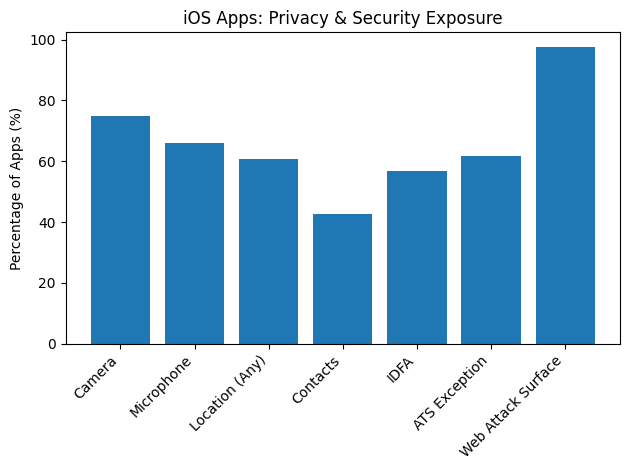

In [ ]:
import matplotlib.pyplot as plt

labels = [
    "Camera",
    "Microphone",
    "Location (Any)",
    "Contacts",
    "IDFA",
    "ATS Exception",
    "Web Attack Surface"
]

values = [
    ios["Uses Camera"].mean() * 100,
    ios["Uses Mic"].mean() * 100,
    ios["Uses_Location_Any_TMP"].mean() * 100,
    ios["Uses Contacts"].mean() * 100,
    ios["Uses IDFA"].mean() * 100,
    ios["ATS Exception Present"].mean() * 100,
    ios["Web_Attack_Surface_TMP"].mean() * 100
]

plt.figure()
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage of Apps (%)")
plt.title("iOS Apps: Privacy & Security Exposure")
plt.tight_layout()
plt.show()


In [ ]:

tracking_ios_df = pd.DataFrame({
    "Tracking Intensity": ["None", "Low", "Medium", "High"],
    "Percentage of Apps (%)": [
        round((ios["Tracking_Intensity_TMP"] == lvl).mean() * 100, 2)
        for lvl in ["None", "Low", "Medium", "High"]
    ]
})

print("\n=== iOS TRACKING INTENSITY DISTRIBUTION ===\n")
print(tracking_ios_df)



=== iOS TRACKING INTENSITY DISTRIBUTION ===

  Tracking Intensity  Percentage of Apps (%)
0               None                   85.00
1                Low                   10.83
2             Medium                    1.67
3               High                    2.50


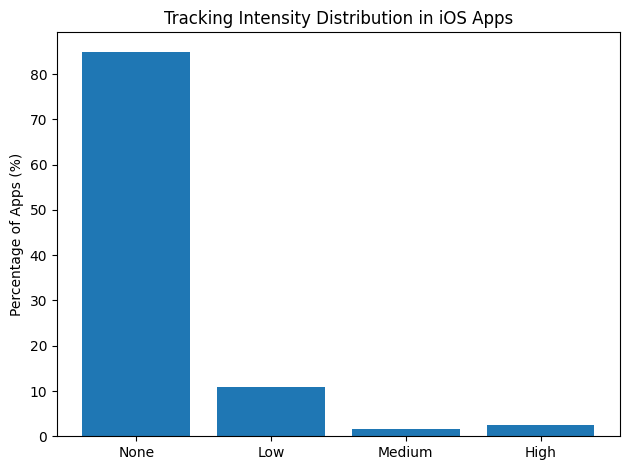

In [ ]:
tracking_levels = ["None", "Low", "Medium", "High"]
tracking_percentages = [
    (ios["Tracking_Intensity_TMP"] == lvl).mean() * 100
    for lvl in tracking_levels
]

plt.figure()
plt.bar(tracking_levels, tracking_percentages)
plt.ylabel("Percentage of Apps (%)")
plt.title("Tracking Intensity Distribution in iOS Apps")
plt.tight_layout()
plt.show()
